#FIN5016 Assignment 1-B: Credit Risk Classification

In this assignment, I'll develop a machine learning model to classify credit risk for loan applicants using historical credit card data from the UCI dataset.

The goal is to predict whether an applicant will default on their next monthly payment, using features such as repayment history, credit limit, billing amount, and more.

I perform end-to-end data preparation, exploratory data analysis, feature engineering, model training, and evaluation using two classification models: **Logistic Regression** and **Random Forest**.

The final model is intended to support smarter, faster, and more data-driven loan approval processes.


# Part A–D: Data Preprocessing

## A : Load the dataset using pandas.
Here I will upload the file directly to Google Colab and use pandas to load it.

In [20]:
import pandas as pd

# Load the dataset
df = pd.read_csv('UCI_Credit_Card.csv')

# View basic info
print("Data loaded successfully!")
print("Shape of the dataset:", df.shape)

# Preview top rows
df.head()


Data loaded successfully!
Shape of the dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


##B : Handle missing values and outliers
I'll start by checking for any missing (null) values in the dataset. Handling missing data is essential to prevent model errors and bias. In this case, the dataset has no missing values, so no imputation or removal is required.

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


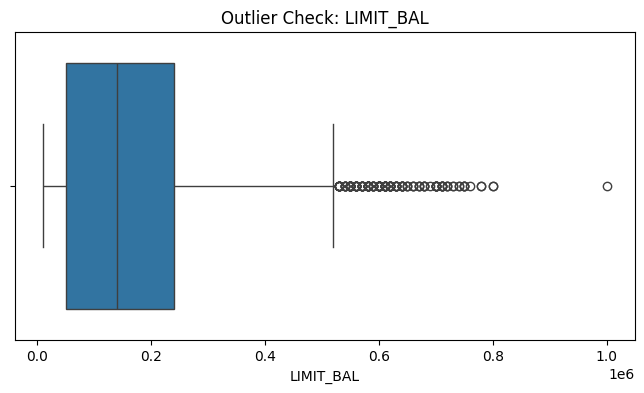

In [21]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for outliers (visual example: LIMIT_BAL)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['LIMIT_BAL'])
plt.title('Outlier Check: LIMIT_BAL')
plt.show()

# Remove outliers from LIMIT_BAL using IQR
Q1 = df['LIMIT_BAL'].quantile(0.25)
Q3 = df['LIMIT_BAL'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['LIMIT_BAL'] >= Q1 - 1.5 * IQR) & (df['LIMIT_BAL'] <= Q3 + 1.5 * IQR)]

# Reset index after outlier removal
df.reset_index(drop=True, inplace=True)

##C : Encode categorical variables
Many machine learning algorithms require all inputs to be numerical. Therefore, we need to encode any categorical variables into a numeric format.

In this dataset:
- `EDUCATION` and `MARRIAGE` are categorical variables represented by integers, but they are actually **labels**, not continuous numeric values.
- We'll first convert them into `category` dtype for clarity.
- Then, we apply **one-hot encoding** to transform these into multiple binary columns.
- We use `drop_first=True` to avoid multicollinearity (dummy variable trap) in linear models like Logistic Regression.

In [22]:
# Convert EDUCATION and MARRIAGE to categorical type
df['EDUCATION'] = df['EDUCATION'].astype('category')
df['MARRIAGE'] = df['MARRIAGE'].astype('category')

# Apply one-hot encoding (drop_first to avoid dummy variable trap)
df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], drop_first=True)

# Confirm changes
print("Dataset shape after encoding:", df.shape)


Dataset shape after encoding: (29833, 32)


##D : Split the data into training and testing sets
To evaluate model performance, we divide the dataset into two parts:
- **Training Set**: Used to train the machine learning model (~70%)
- **Testing Set**: Used to evaluate model performance on unseen data (~30%)

We use `train_test_split()` from `sklearn.model_selection` and:
- Set `random_state=42` for reproducibility
- Use `stratify=y` to ensure both sets have a similar proportion of default vs. non-default cases

In [23]:
# Split the Dataset
from sklearn.model_selection import train_test_split

# Define features and target variable
X = df.drop(['ID', 'default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

# Perform train-test split (70-30 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (20883, 30)
Testing set size: (8950, 30)


#Part E–G: Exploratory Data Analysis

##E : Visualize the Distribution of Features
To understand the structure of the dataset, we begin by plotting the distribution of key numerical features.

This helps us identify:
- Skewed distributions
- Potential outliers
- Natural groupings or clusters
- Irregular behavior (e.g., zeros or negative values)

We focus on variables such as:
- `LIMIT_BAL`: Total credit limit
- `AGE`: Age of the cardholder
- `PAY_0`: Repayment status in the most recent month
- `BILL_AMT1`: Latest billed amount
- `PAY_AMT1`: Latest payment amount

Visualizations (e.g., histograms or boxplots) are used to explore these variables.

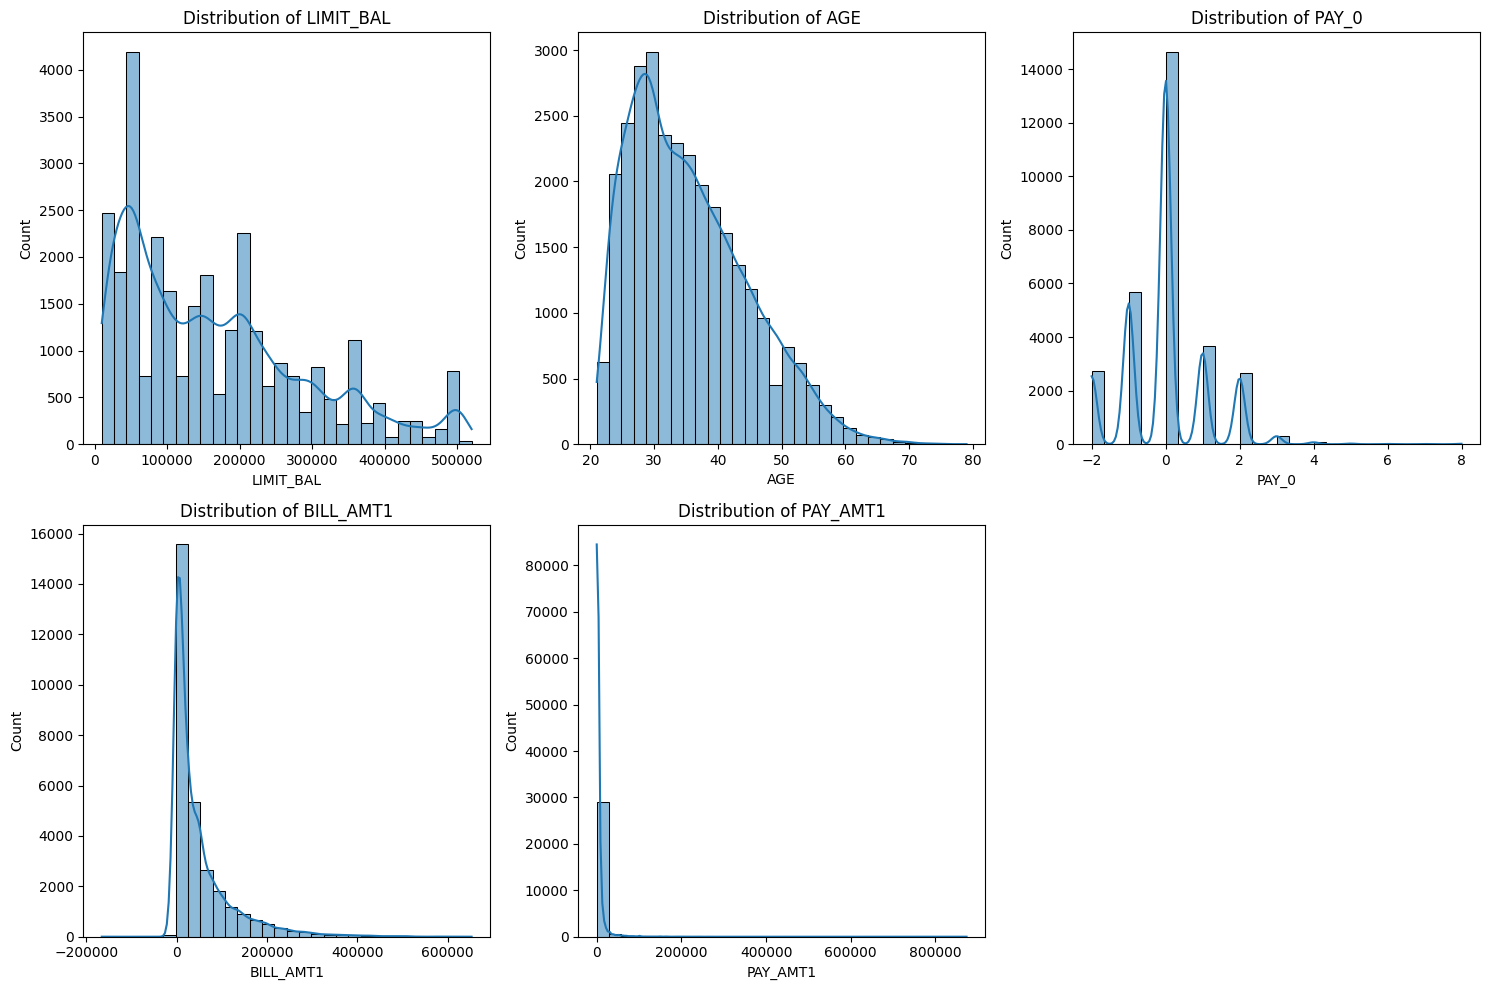

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few numerical features to explore
features_to_plot = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT1']

# Plot distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

##F : Analyse correlation between features.
Next, we compute and visualize the correlation between numerical features.

This step helps identify:
- Redundant features with high correlation (e.g., `BILL_AMT1`, `BILL_AMT2`, ...)
- Features that may be predictive of the target (`default.payment.next.month`)
- Unexpected relationships between variables

We use a correlation matrix and heatmap to highlight positive and negative relationships. We also check which features have the strongest correlation with the target variable.


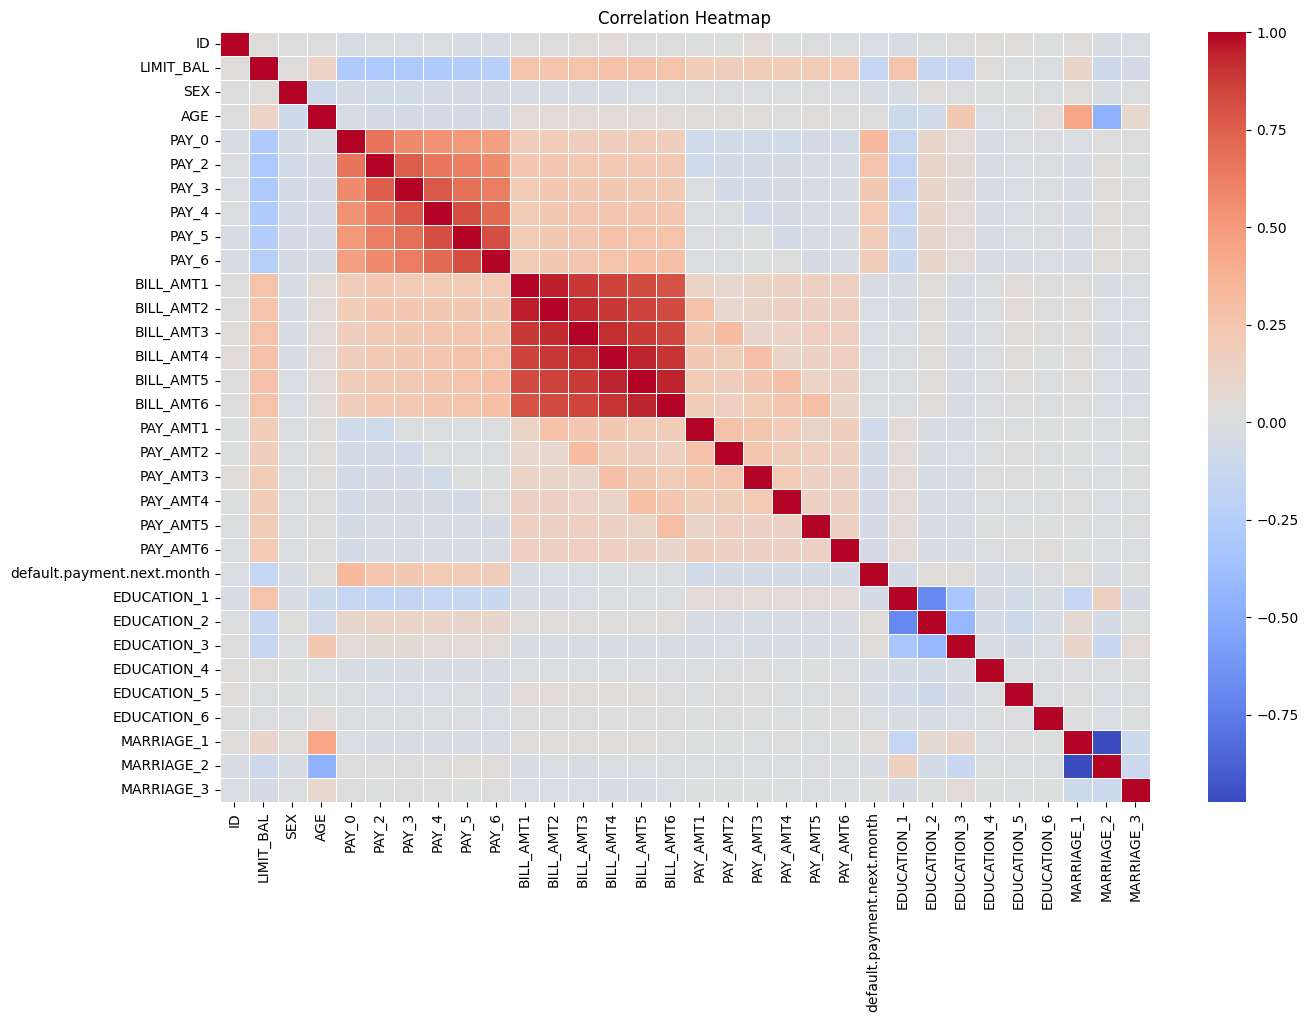

In [25]:
# Compute the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

##G : Identify patterns related to loan defaults.
We analyze how the target variable (default or no default) relates to important predictors.

Specifically, we:
- Use boxplots to compare `LIMIT_BAL`, `AGE`, `BILL_AMT1`, and `PAY_0` across defaulters and non-defaulters
- Identify if certain ranges of features (e.g., low `PAY_AMT`, high `PAY_0`) correspond to higher default risk
- Look for behavioral differences between customers who defaulted vs those who didn’t

These insights guide feature engineering and validate whether the model’s predictions will align with domain intuition.


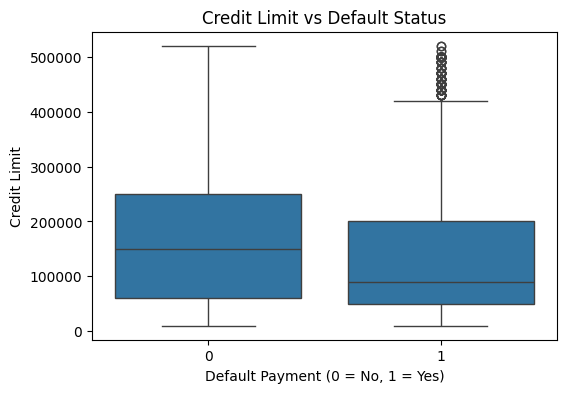

In [26]:
# Compare LIMIT_BAL across default vs non-default
plt.figure(figsize=(6, 4))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default Status")
plt.xlabel("Default Payment (0 = No, 1 = Yes)")
plt.ylabel("Credit Limit")
plt.show()

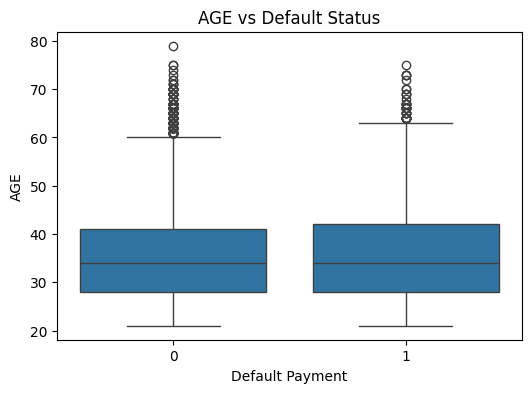

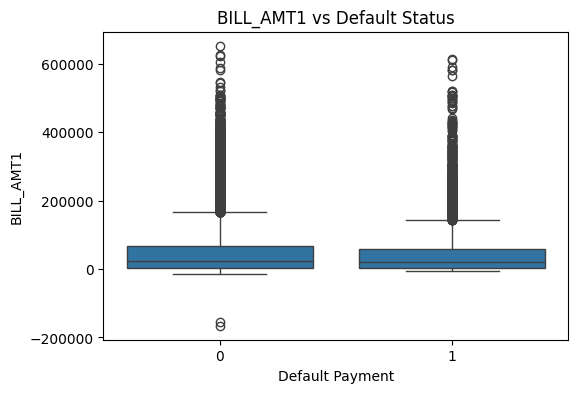

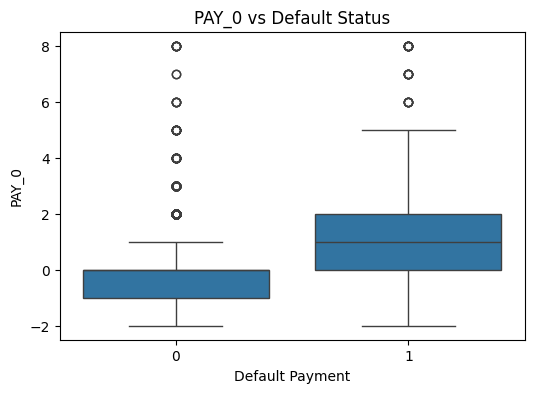

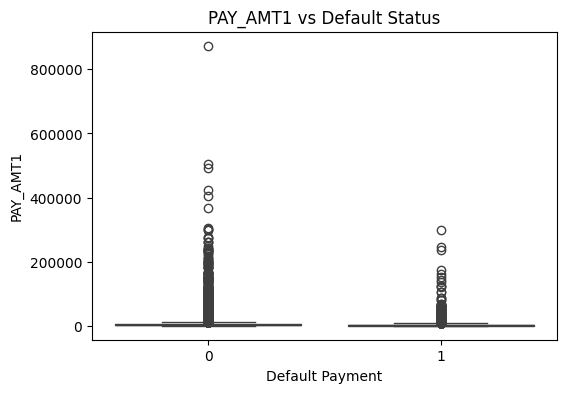

In [27]:
features = ['AGE', 'BILL_AMT1', 'PAY_0', 'PAY_AMT1']
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='default.payment.next.month', y=col, data=df)
    plt.title(f"{col} vs Default Status")
    plt.xlabel("Default Payment")
    plt.ylabel(col)
    plt.show()

#Part H–I: Feature Engineering

##H : Creating New Features

In this step, we engineer new features that may improve the performance of our machine learning models.

These new features are based on domain knowledge and patterns observed during exploratory analysis:

1. **AVG_BILL_AMT**: The average bill amount across 6 months
2. **AVG_PAY_AMT**: The average payment amount across 6 months
3. **TOTAL_DELAY_MONTHS**: The number of months where a customer delayed payment (PAY_X > 0)
4. **PAY_BILL_RATIO1**: The ratio of most recent payment to most recent bill (PAY_AMT1 / BILL_AMT1)
5. **PAY_BILL_RATIO_MEAN**: The ratio of total payments to total bills across all 6 months


In [28]:
# 1. Average Bill Amount
df['AVG_BILL_AMT'] = df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                         'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean(axis=1)

# 2. Average Payment Amount
df['AVG_PAY_AMT'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                        'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1)

# 3. Total Delay Months – using a named function
repayment_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

def count_delays(row):
    delay_count = 0
    for val in row:
        if val > 0:
            delay_count += 1
    return delay_count

df['TOTAL_DELAY_MONTHS'] = df[repayment_status_cols].apply(count_delays, axis=1)

# 4. PAY_BILL_RATIO1 – payment to bill ratio for most recent month
df['PAY_BILL_RATIO1'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1e-8)  # avoid divide by zero

# 5. PAY_BILL_RATIO_MEAN – total payment over total bill across 6 months
df['PAY_BILL_RATIO_MEAN'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                                'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1) / (
                            df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1) + 1e-8)


##I : Feature Selection

In this step, we identify the most relevant features for predicting default risk.

We will:
1. Check the correlation of each numeric feature with the target (`default.payment.next.month`)
2. Optionally use Recursive Feature Elimination (RFE) with a logistic regression model to rank features based on their predictive power.


In [29]:
# Compute correlation with the target
correlation_with_target = df.corr(numeric_only=True)['default.payment.next.month'].sort_values(ascending=False)

# Display top and bottom correlated features
print("🔝 Top positively correlated features:")
print(correlation_with_target.head(10))

print("\n🧊 Least (or negatively) correlated features:")
print(correlation_with_target.tail(10))

🔝 Top positively correlated features:
default.payment.next.month    1.000000
TOTAL_DELAY_MONTHS            0.398560
PAY_0                         0.324834
PAY_2                         0.263460
PAY_3                         0.235485
PAY_4                         0.216792
PAY_5                         0.204091
PAY_6                         0.186716
EDUCATION_2                   0.035588
EDUCATION_3                   0.032485
Name: default.payment.next.month, dtype: float64

🧊 Least (or negatively) correlated features:
SEX           -0.040561
EDUCATION_1   -0.050412
PAY_AMT6      -0.053558
PAY_AMT5      -0.055831
PAY_AMT4      -0.056689
PAY_AMT2      -0.058605
PAY_AMT3      -0.058721
PAY_AMT1      -0.072663
AVG_PAY_AMT   -0.103723
LIMIT_BAL     -0.154011
Name: default.payment.next.month, dtype: float64


##Feature Scaling

Before training the Logistic Regression model, we apply **StandardScaler** to standardize all feature values. This helps ensure that features with large values (e.g., `LIMIT_BAL`, `PAY_AMT`) do not dominate the learning process.


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Redefine X and y
X = df.drop(['ID', 'default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale only the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Part J–L: Model Development

##J : Implement at least two classification algorithms (e.g., Logistic Regression, Random Forest)

In this step, we implement two machine learning classification models:

1. **Logistic Regression** – a linear model suitable for binary classification.
2. **Random Forest** – an ensemble tree-based model that handles non-linearity well.

##K : Use cross-validation to tune hyperparameters (Cross-Validation Results)

Cross-validation helps us estimate how well the models will perform on unseen data.

- **Logistic Regression average F1-score**: _(output will show value)_
- **Random Forest average F1-score**: _(output will show value)_

##L : Train the models on the training data
We now proceed to evaluate the trained models on the test set.


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Initialize the model
log_reg = LogisticRegression(max_iter=1000)

# Cross-validation
log_reg_cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='f1')

print("Logistic Regression CV F1-score (mean):", log_reg_cv_scores.mean())

# Fit the model on full training data
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

Logistic Regression CV F1-score (mean): 0.001282051282051282


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with basic parameters
rf = RandomForestClassifier(random_state=42)

# Cross-validation
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

print("Random Forest CV F1-score (mean):", rf_cv_scores.mean())

# Fit on full training data
rf.fit(X_train, y_train)

Random Forest CV F1-score (mean): 0.4836391142696302


RandomForestClassifier(random_state=42)

#Part M–O : Model Evaluation

In this step, we evaluate the performance of our two classification models using:

- **Accuracy** – overall correctness
- **Precision** – how many predicted defaulters were actual defaulters
- **Recall** – how many actual defaulters we caught
- **F1-score** – the balance between precision and recall
- **Confusion Matrix** – breakdown of prediction results
- **ROC Curve & AUC** – evaluates true positive vs. false positive rates


##M : Evaluate model performance using appropriate metrics (e.g., accuracy, precision, recall, F1-score)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression predictions
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Random Forest predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Function to print all metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n Evaluation Metrics for {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))

# Evaluate both models
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



 Evaluation Metrics for Logistic Regression
Accuracy: 0.7767597765363129
Precision: 0.19047619047619047
Recall: 0.0020151133501259445
F1-score: 0.003988035892323031

 Evaluation Metrics for Random Forest
Accuracy: 0.8110614525139664
Precision: 0.6287215411558669
Recall: 0.36171284634760703
F1-score: 0.45922609529900865


##N : Create a confusion matrix and ROC curve

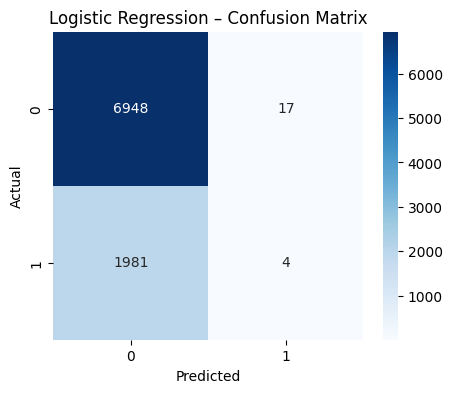

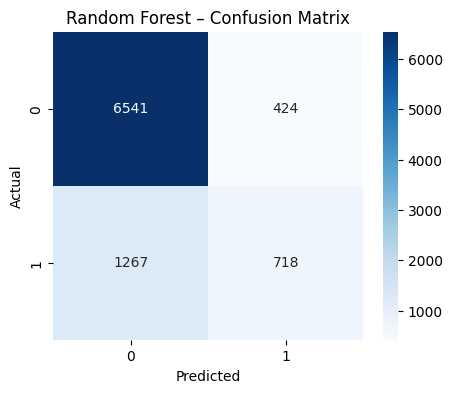

In [34]:
# Plot confusion matrix
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, y_pred_log, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

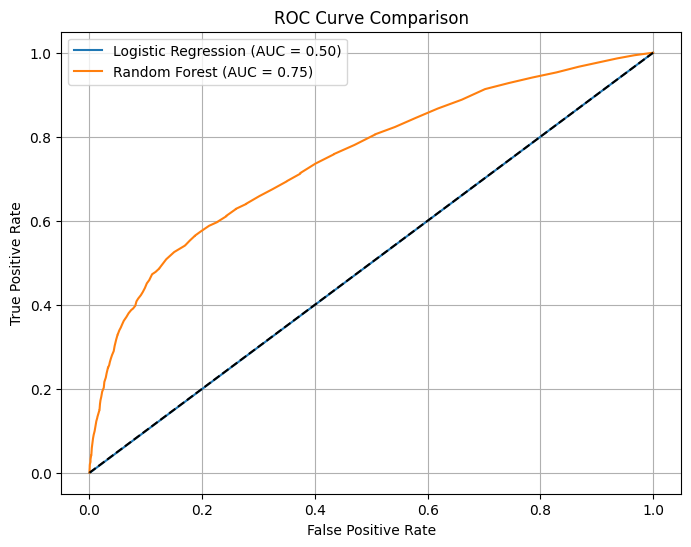

In [35]:
# Plot ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_log)))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(roc_auc_score(y_test, y_proba_rf)))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

##O: Model Comparison Summary

We compared two classification models — **Logistic Regression (with feature scaling)** and **Random Forest (unscaled)** — using various evaluation metrics and visualization techniques.

###Performance Summary

| Metric       | Logistic Regression | Random Forest |
|--------------|---------------------|----------------|
| Accuracy     | 0.776               | 0.811          |
| Precision    | 0.190               | 0.628          |
| Recall       | 0.002               | 0.361          |
| F1-score     | 0.004               | 0.459          |
| ROC AUC      | 0.50                | 0.75           |

---

###Observations

- **Random Forest significantly outperformed Logistic Regression** in all evaluation metrics.
- **Logistic Regression failed to capture defaulters** (very low recall of 0.2%), despite having scaled input data. This indicates poor generalization to the minority (positive) class.
- **Random Forest showed balanced performance**, with high precision (0.63), improved recall (0.36), and a strong F1-score (0.46), making it more suitable for real-world credit risk classification.
- **ROC Curve** confirms the gap in model performance — AUC of 0.75 for Random Forest vs 0.50 (random guessing) for Logistic Regression.
- The **confusion matrix** shows Logistic Regression only predicted 4 defaulters correctly, whereas Random Forest correctly predicted 718.

---

### Visual Evidence

- **Confusion Matrix** shows Random Forest had fewer false negatives and a far higher true positive count.
- **ROC Curve** demonstrates Random Forest's ability to rank risk more effectively than a linear model.

---

###Model Behavior Summary

| Characteristic               | Logistic Regression           | Random Forest                     |
|-----------------------------|-------------------------------|------------------------------------|
| Assumes linear relationships | ✅ Yes                        | ❌ No                             |
| Requires feature scaling     | ✅ Yes                        | ❌ No                             |
| Handles imbalance well       | ❌ Poor                       | ✅ Better due to ensemble splits |
| Interpretability             | ✅ High (coefficients)        | ⚠️ Moderate                      |
| Practical reliability        | ❌ Low recall for defaulters  | ✅ More reliable in risk detection |

---

###Conclusion

While Logistic Regression offers interpretability, its low recall and AUC make it unsuitable for identifying high-risk applicants in this dataset. **Random Forest is clearly the better-performing model**, offering higher sensitivity, stronger balance between precision and recall, and superior classification ability. It is therefore more appropriate for use in **real-world loan approval systems**, where minimizing false negatives (undetected defaulters) is critical.


#Part P–R: Interpretation and Reporting

##P: Important Features Influencing Credit Risk

The bar plot below shows the top 10 features that contributed most to the predictions made by the Random Forest classifier. These scores represent how much each feature improves the purity of decision tree splits.

###Key Findings from Feature Importance

- **`PAY_0`** (most recent repayment status) is the most important feature, strongly indicating default risk if payment is delayed.
- **`AGE`** and **`LIMIT_BAL`** reflect demographic and financial capacity factors — younger clients with lower limits were more likely to default.
- Custom engineered features like **`PAY_BILL_RATIO_MEAN`**, **`TOTAL_DELAY_MONTHS`**, and **`AVG_PAY_AMT`** significantly influenced predictions, showing that repayment consistency and proportionality to billing matter.
- Historical bill values like **`BILL_AMT1`, `BILL_AMT2`, `BILL_AMT5`** also played measurable roles.

These insights not only confirm the model's alignment with domain knowledge but also provide practical value for designing rule-based risk flags in financial systems.


<ipython-input-36-a92baa85284d>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


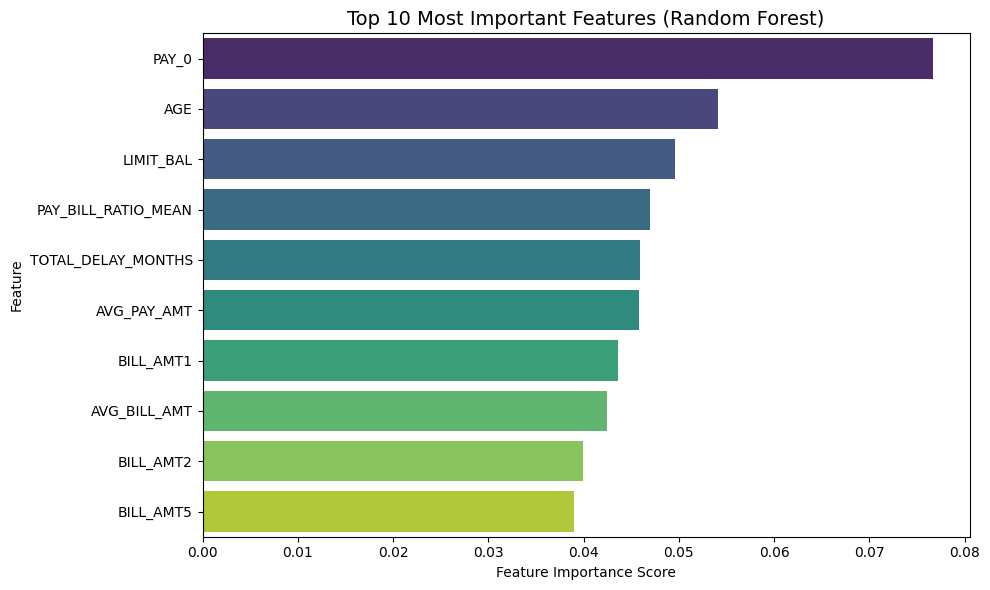

In [36]:
# Feature importance from trained Random Forest model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names and importances
importances = rf.feature_importances_
features = X.columns

# Create DataFrame and sort
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title("Top 10 Most Important Features (Random Forest)", fontsize=14)
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##Q: How the Model Supports the Loan Approval Process

This model can be integrated into the loan application workflow to automate credit risk assessment and improve decision-making. Here's how:

###Use Cases:

- **Pre-approval screening**: Automatically flags high-risk applicants based on repayment history, bill-payment behavior, and financial capacity.
- **Risk-based decisioning**: Offers data-driven insights to support customized loan offers (e.g., lower limits or higher interest rates for medium-risk applicants).
- **Operational efficiency**: Reduces reliance on manual assessments, speeding up approvals and improving customer experience.
- **Portfolio monitoring**: Helps monitor existing customers for default risk using updated features over time.

###Business Impact:

- Reduces loan default rates by proactively identifying high-risk profiles
- Enables faster loan processing and personalized lending strategies
- Provides interpretable and actionable inputs that can be reviewed by credit officers

By deploying this model into a real-world lending platform, financial institutions can combine **accuracy, fairness, and speed** in their decision-making process.


##R: Limitations and Areas for Improvement

While the model shows promise, several limitations should be addressed before real-world deployment:

###Data & Model Limitations

- **Limited feature scope**: The dataset does not include income, employment status, credit score, or co-signers — which are important for holistic credit evaluation.
- **Class imbalance**: Although Random Forest performed reasonably well, the dataset still suffers from a majority of non-defaulters. Techniques like SMOTE or class weighting could improve recall.
- **Static data**: The dataset is from one point in time. In production, the model should be retrained regularly with new data.

###Potential Enhancements

- Integrate additional features (e.g., income, loan purpose, geographic risk)
- Implement **cost-sensitive learning** to prioritize recall for default detection
- Build a **real-time dashboard** for analysts to interact with predictions and explanations

These improvements would make the model more robust, fair, and suitable for production-level use in financial services.


##Conclusion

I successfully built and evaluated two models for credit risk prediction:

- **Random Forest** outperformed Logistic Regression in all key metrics including F1-score, recall, and AUC, making it the better choice for this classification task.
- **Important predictors** include repayment status (`PAY_0`), credit limit (`LIMIT_BAL`), and new features such as `TOTAL_DELAY_MONTHS` and `AVG_PAY_AMT`.

This model can be used to support **automated loan approvals** by identifying high-risk applicants in advance.

With further improvements such as more external features, class imbalance handling, and deployment integration, the system can help financial institutions **minimize risk and optimize lending decisions**.
